1. Import dataset from drive, so you gotta upload the file there

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)


Mounted at /content/drive


2. Load Dataset

In [2]:
CSV_PATH = "/content/drive/MyDrive/Cognitive_Security/mental_health_wearable_data.csv"
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()



Shape: (500, 13)
Columns: ['Timestamp', 'EEG_Frequency_Bands', 'GSR_Values', 'Cognitive_State', 'Emotional_State', 'Student_ID', 'Age', 'Gender', 'Session_Type', 'Duration (minutes)', 'Environmental_Context', 'Preprocessed_Features', 'Target']


,Timestamp,EEG_Frequency_Bands,GSR_Values,Cognitive_State,Emotional_State,Student_ID,Age,Gender,Session_Type,Duration (minutes),Environmental_Context,Preprocessed_Features,Target
0,2025-01-01 10:00:00,"[7.400574384984986, 5.621240954745124, 4.62440...",1.376494,Distracted,Anxious,151,19,Female,Study,43,Library,"(0.09206977288455342, 0.3621872664986312)",0
1,2025-01-01 10:05:00,"[1.6898477932146672, 7.2616994947041125, 1.106...",0.084319,Focused,Stressed,150,20,Male,Test,49,Home,"(0.6630302454051626, 0.16534951688386967)",1
2,2025-01-01 10:10:00,"[0.2693319401287453, 8.909349692334239, 7.2444...",0.895629,Cognitive Overload,Anxious,173,24,Male,Test,56,Library,"(0.01057761975425231, 0.20044284523215694)",1
3,2025-01-01 10:15:00,"[6.080175212895389, 6.387554935291081, 9.09906...",0.386398,Focused,Anxious,171,22,Male,Relaxation,48,Library,"(0.2924924921884593, 0.8773068202243881)",1
4,2025-01-01 10:20:00,"[5.9007231710422525, 8.301537594579075, 4.4649...",1.186898,Focused,Anxious,131,22,Female,Relaxation,57,Home,"(0.7670629457831021, 0.5652674255918193)",0


3. Binary labels

Threat (1) → anxious, stressed, overloaded, distracted

Safe (0) → calm, focused

In [3]:
# Threat (1) → anxious, stressed, overloaded, distracted
# Safe (0) → calm, focused

df2 = df.copy()

# Normalize text just in case (strip spaces)
df2["Cognitive_State"] = df2["Cognitive_State"].astype(str).str.strip()

label_map = {
    # Threat
    "anxious": 1, "stressed": 1, "overloaded": 1, "distracted": 1,
    "Anxious": 1, "Stressed": 1, "Overloaded": 1, "Distracted": 1,

    # Safe
    "calm": 0, "focused": 0,
    "Calm": 0, "Focused": 0,

    # Your dataset variants (very important)
    "Cognitive Overload": 1
}

df2["y_bin"] = df2["Cognitive_State"].map(label_map)

# Drop any rows that didn't map cleanly
df2 = df2.dropna(subset=["y_bin"]).reset_index(drop=True)
df2["y_bin"] = df2["y_bin"].astype(int)

print("Binary label counts (0=Safe, 1=Threat):")
print(df2["y_bin"].value_counts())
print("\nUnique Cognitive_State values after cleanup:")
print(sorted(df2["Cognitive_State"].unique()))


Binary label counts (0=Safe, 1=Threat):
y_bin
1    341
0    159
Name: count, dtype: int64

Unique Cognitive_State values after cleanup:
['Cognitive Overload', 'Distracted', 'Focused']


4. Preprocessing: Categorical data --> Binary matrix

In [4]:
# Drop timestamp if present
if "Timestamp" in df2.columns:
    df2 = df2.drop(columns=["Timestamp"])

# Feature columns (adjust if needed)
base_cols = [c for c in ["GSR_Values", "Age", "Duration (minutes)"] if c in df2.columns]
eeg_cols  = [c for c in df2.columns if c.startswith("EEG_")]
prep_cols = [c for c in df2.columns if c.startswith("Preprocessed_")]
demo_cols = [c for c in ["Gender"] if c in df2.columns]  # keep for fairness later

feature_cols = base_cols + eeg_cols + prep_cols + demo_cols
print("Using features:", feature_cols)

X = df2[feature_cols].copy()

# One-hot encode categorical columns (Gender, etc.)
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

y = df2["y_bin"].values

print("X shape:", X.shape, "y shape:", y.shape)


Using features: ['GSR_Values', 'Age', 'Duration (minutes)', 'EEG_Frequency_Bands', 'Preprocessed_Features', 'Gender']
X shape: (500, 1005) y shape: (500,)


5. Train-Test split + Scaling

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train counts:", pd.Series(y_train).value_counts().to_dict())
print("Test counts:", pd.Series(y_test).value_counts().to_dict())


Train: (400, 1005) Test: (100, 1005)
Train counts: {1: 273, 0: 127}
Test counts: {1: 68, 0: 32}


6. Class weights for imbalance

In [6]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weights:", class_weight_dict)


Class weights: {0: 1.5748031496062993, 1: 0.7326007326007326}


7. Evaluation function

In [7]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

def eval_binary(name, model, X_te, y_te):
    y_pred = model.predict(X_te)

    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_te, y_pred), 4))
    print("Balanced Acc:", round(balanced_accuracy_score(y_te, y_pred), 4))
    print("Precision (Threat=1):", round(precision_score(y_te, y_pred, zero_division=0), 4))
    print("Recall (Threat=1):", round(recall_score(y_te, y_pred, zero_division=0), 4))
    print("F1 (Threat=1):", round(f1_score(y_te, y_pred, zero_division=0), 4))

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
        print("ROC-AUC:", round(roc_auc_score(y_te, y_prob), 4))

    print("\nReport:\n", classification_report(
        y_te, y_pred,
        target_names=["Safe(0)", "Threat(1)"],
        zero_division=0
    ))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()

    return y_pred

8. Logistic Regression


=== Logistic Regression (balanced) ===
Accuracy: 0.68
Balanced Acc: 0.5
Precision (Threat=1): 0.68
Recall (Threat=1): 1.0
F1 (Threat=1): 0.8095
ROC-AUC: 0.4301

Report:
               precision    recall  f1-score   support

     Safe(0)       0.00      0.00      0.00        32
   Threat(1)       0.68      1.00      0.81        68

    accuracy                           0.68       100
   macro avg       0.34      0.50      0.40       100
weighted avg       0.46      0.68      0.55       100



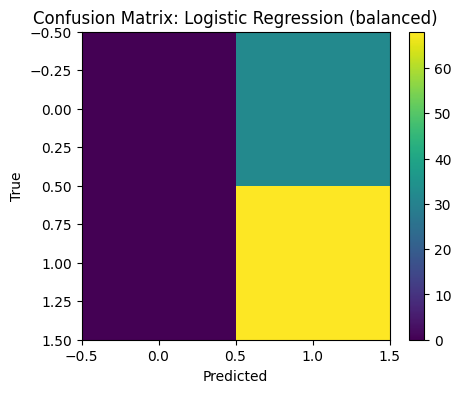

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=4000, random_state=SEED, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

y_pred_lr = eval_binary("Logistic Regression (balanced)", lr, X_test_scaled, y_test)

9. Random Forest


=== Random Forest (balanced) ===
Accuracy: 0.68
Balanced Acc: 0.5
Precision (Threat=1): 0.68
Recall (Threat=1): 1.0
F1 (Threat=1): 0.8095
ROC-AUC: 0.4628

Report:
               precision    recall  f1-score   support

     Safe(0)       0.00      0.00      0.00        32
   Threat(1)       0.68      1.00      0.81        68

    accuracy                           0.68       100
   macro avg       0.34      0.50      0.40       100
weighted avg       0.46      0.68      0.55       100



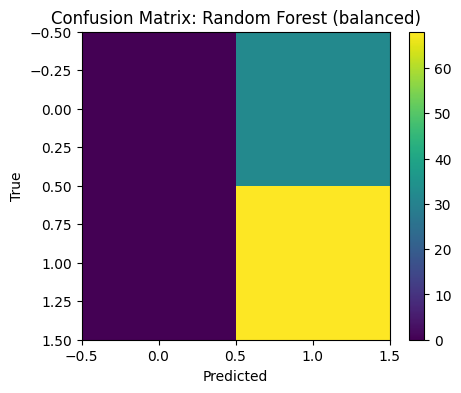

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

y_pred_rf = eval_binary("Random Forest (balanced)", rf, X_test, y_test)

10. SVM


=== SVM (RBF, balanced) ===
Accuracy: 0.68
Balanced Acc: 0.5
Precision (Threat=1): 0.68
Recall (Threat=1): 1.0
F1 (Threat=1): 0.8095
ROC-AUC: 0.5685

Report:
               precision    recall  f1-score   support

     Safe(0)       0.00      0.00      0.00        32
   Threat(1)       0.68      1.00      0.81        68

    accuracy                           0.68       100
   macro avg       0.34      0.50      0.40       100
weighted avg       0.46      0.68      0.55       100



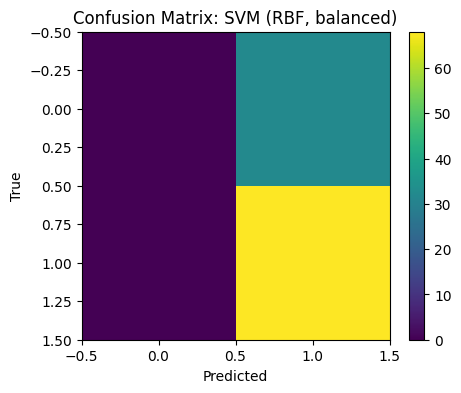

In [10]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=SEED,
    class_weight="balanced"
)
svm.fit(X_train_scaled, y_train)

y_pred_svm = eval_binary("SVM (RBF, balanced)", svm, X_test_scaled, y_test)

11.

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


12. MLP

In [12]:
tf.random.set_seed(SEED)

input_dim = X_train_scaled.shape[1]

mlp_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

y_prob_mlp = mlp_model.predict(X_test_scaled).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

# Quick eval
print("\n=== MLP (Keras, balanced) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Balanced Acc:", round(balanced_accuracy_score(y_test, y_pred_mlp), 4))
print("Precision (Threat=1):", round(precision_score(y_test, y_pred_mlp, zero_division=0), 4))
print("Recall (Threat=1):", round(recall_score(y_test, y_pred_mlp, zero_division=0), 4))
print("F1 (Threat=1):", round(f1_score(y_test, y_pred_mlp, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_mlp), 4))
print(classification_report(y_test, y_pred_mlp, target_names=["Safe(0)", "Threat(1)"], zero_division=0))


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.4369 - loss: 0.9541 - val_accuracy: 0.4667 - val_loss: 0.7965
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6033 - loss: 0.7688 - val_accuracy: 0.4833 - val_loss: 0.7645
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6752 - loss: 0.6709 - val_accuracy: 0.5000 - val_loss: 0.7660
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6634 - loss: 0.6158 - val_accuracy: 0.4500 - val_loss: 0.7841
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7759 - loss: 0.4939 - val_accuracy: 0.4000 - val_loss: 0.8074
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7700 - loss: 0.4598 - val_accuracy: 0.4000 - val_loss: 0.8204
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8165 - loss: 0.4167 - val_accuracy: 0.4000 - val_loss: 0.8221
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

=== MLP (Keras, balanced) ===
Accuracy: 0.68
Balanced Acc: 0.5
Precision (Threat=1): 

13. 1D CNN

In [13]:
tf.random.set_seed(SEED)

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0],  X_test_scaled.shape[1], 1)

cnn_model = keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(64, 3, activation="relu"),
    layers.Conv1D(32, 3, activation="relu"),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]

cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

y_prob_cnn = cnn_model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

print("\n=== 1D CNN (Keras, balanced) ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_cnn), 4))
print("Balanced Acc:", round(balanced_accuracy_score(y_test, y_pred_cnn), 4))
print("Precision (Threat=1):", round(precision_score(y_test, y_pred_cnn, zero_division=0), 4))
print("Recall (Threat=1):", round(recall_score(y_test, y_pred_cnn, zero_division=0), 4))
print("F1 (Threat=1):", round(f1_score(y_test, y_pred_cnn, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_cnn), 4))
print(classification_report(y_test, y_pred_cnn, target_names=["Safe(0)", "Threat(1)"], zero_division=0))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 378ms/step - accuracy: 0.5358 - loss: 0.6941 - val_accuracy: 0.5667 - val_loss: 0.6848
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.9628 - loss: 0.4311 - val_accuracy: 0.6000 - val_loss: 0.7436
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - accuracy: 0.9721 - loss: 0.2580 - val_accuracy: 0.5667 - val_loss: 0.9017
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.9790 - loss: 0.1368 - val_accuracy: 0.5333 - val_loss: 1.2080
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.9819 - loss: 0.0730 - val_accuracy: 0.5833 - val_loss: 1.6167
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.9907 - loss: 0.0355 - val_accuracy: 0.5833 - val_loss: 2.0504
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

=== 1D CNN (Keras, balanced) ===
Accuracy: 0.69
Balanced Acc: 0.5156
Precision (Threat=1): 0.6869
Recall (Threat=1): 1.0
F1 (Threat=1): 0.8144
ROC-AUC: 0.6011
              precision    recall  f1-score   

14. Results

In [14]:
from sklearn.metrics import roc_auc_score

rows = []

def add_row(name, y_pred, y_prob=None):
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_test, y_pred),
        "Precision(Threat)": precision_score(y_test, y_pred, zero_division=0),
        "Recall(Threat)": recall_score(y_test, y_pred, zero_division=0),
        "F1(Threat)": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    })

add_row("LogReg", y_pred_lr, lr.predict_proba(X_test_scaled)[:, 1])
add_row("RandomForest", y_pred_rf, rf.predict_proba(X_test)[:, 1])
add_row("SVM", y_pred_svm, svm.predict_proba(X_test_scaled)[:, 1])
add_row("MLP", y_pred_mlp, y_prob_mlp)
add_row("1D CNN", y_pred_cnn, y_prob_cnn)

results_df = (
    pd.DataFrame(rows)
    .sort_values(by="F1(Threat)", ascending=False)
    .reset_index(drop=True)
)

results_df.style.set_caption(
    "Baseline Results: Threat = Cognitive Overload + Distracted, Safe = Focused"
)


,Model,Accuracy,Balanced_Acc,Precision(Threat),Recall(Threat),F1(Threat),ROC_AUC
0,1D CNN,0.690000,0.515625,0.686869,1.000000,0.814371,0.601103
1,LogReg,0.680000,0.500000,0.680000,1.000000,0.809524,0.430147
2,RandomForest,0.680000,0.500000,0.680000,1.000000,0.809524,0.462776
3,SVM,0.680000,0.500000,0.680000,1.000000,0.809524,0.568474
4,MLP,0.680000,0.500000,0.680000,1.000000,0.809524,0.540901
